6. Write a program to simulate and analyze daily stock prices over one year and generate

the stock prices, calculate some basic metrics, and visualize the data with additional
features like moving averages and visualize the same.


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Simulate Daily Stock Prices over One Year ---

# Define parameters for simulation
start_date = '2023-01-01'
end_date = '2023-12-31'
dates = pd.date_range(start=start_date, end=end_date, freq='D')
n_days = len(dates)

initial_price = 100
drift = 0.0005 # Average daily return
volatility = 0.01 # Daily standard deviation of returns

# Generate daily returns (random walk with drift)
daily_returns_sim = np.random.normal(drift, volatility, n_days)

# Simulate stock prices
stock_prices = [initial_price]
for i in range(1, n_days):
    stock_prices.append(stock_prices[-1] * (1 + daily_returns_sim[i]))

# Create a DataFrame for stock prices
stock_df = pd.DataFrame({
    'Date': dates,
    'Price': stock_prices
})
stock_df.set_index('Date', inplace=True)

# Calculate daily returns
stock_df['Daily_Return'] = stock_df['Price'].pct_change() * 100

# Calculate cumulative returns
stock_df['Cumulative_Return'] = (stock_df['Price'] / initial_price - 1) * 100

# Calculate 20-day Simple Moving Average (SMA)
stock_df['SMA_20'] = stock_df['Price'].rolling(window=20).mean()

# Calculate 50-day Simple Moving Average (SMA)
stock_df['SMA_50'] = stock_df['Price'].rolling(window=50).mean()

print("Simulated Stock Prices with Metrics (Head):")
display(stock_df.head())

Simulated Stock Prices with Metrics (Head):


,Price,Daily_Return,Cumulative_Return,SMA_20,SMA_50
Date,,,,,
2023-01-01,100.000000,NaN,0.000000,NaN,NaN
2023-01-02,100.063447,0.063447,0.063447,NaN,NaN
2023-01-03,99.417087,-0.645950,-0.582913,NaN,NaN
2023-01-04,98.690389,-0.730959,-1.309611,NaN,NaN
2023-01-05,98.107665,-0.590457,-1.892335,NaN,NaN


### Visualize Daily Percentage Change

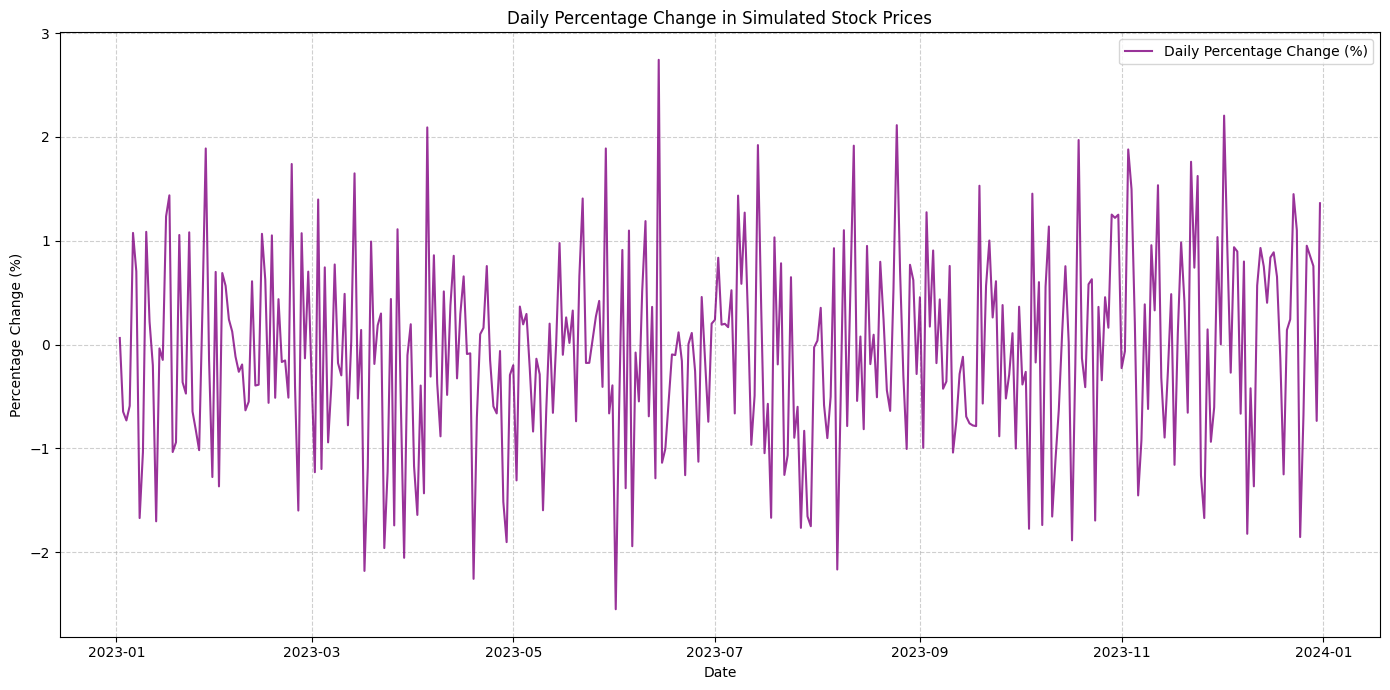

In [50]:
plt.figure(figsize=(14, 7))
plt.plot(stock_df.index, stock_df['Daily_Return'], label='Daily Percentage Change (%)', color='purple', alpha=0.8)
plt.title('Daily Percentage Change in Simulated Stock Prices')
plt.xlabel('Date')
plt.ylabel('Percentage Change (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()